## Final Project

#### Khai báo thư viện

In [1]:

import pandas as pd
import numpy as np
# Load data
df = pd.read_csv("auto_imports.csv")
# Xem dữ liệu
print("=== HEAD ===")
print(df.head())



print("\n=== INFO ===")
df.info()
print("\n=== DESCRIBE ===")
print(df.describe())

print("\n=== COLUMNS ===")
print(df.columns)

# Target
target = "price"

# Missing value trước khi xử lý
print("\n=== MISSING BEFORE ===")
print(df.isnull().sum())
# Xử lý dấu ?
df.replace("?", np.nan, inplace=True)
# Missing value sau khi xử lý
print("\n=== MISSING AFTER ===")
print(df.isnull().sum())


=== HEAD ===
   3    ?  alfa-romero  gas  std   two  convertible  rwd  front  88.60  ...  \
0  3    ?  alfa-romero  gas  std   two  convertible  rwd  front   88.6  ...   
1  1    ?  alfa-romero  gas  std   two    hatchback  rwd  front   94.5  ...   
2  2  164         audi  gas  std  four        sedan  fwd  front   99.8  ...   
3  2  164         audi  gas  std  four        sedan  4wd  front   99.4  ...   
4  2    ?         audi  gas  std   two        sedan  fwd  front   99.8  ...   

   130  mpfi  3.47  2.68  9.00  111  5000  21  27  13495  
0  130  mpfi  3.47  2.68   9.0  111  5000  21  27  16500  
1  152  mpfi  2.68  3.47   9.0  154  5000  19  26  16500  
2  109  mpfi  3.19  3.40  10.0  102  5500  24  30  13950  
3  136  mpfi  3.19  3.40   8.0  115  5500  18  22  17450  
4  136  mpfi  3.19  3.40   8.5  110  5500  19  25  15250  

[5 rows x 26 columns]

=== INFO ===
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 26 columns):
 #   Column       Non-Null 

#### Khai báo tên cột

In [2]:
# Fix: Dataset không có header

columns = [
    "symboling", "normalized_losses", "make", "fuel_type", "aspiration",
    "num_of_doors", "body_style", "drive_wheels", "engine_location",
    "wheel_base", "length", "width", "height", "curb_weight",
    "engine_type", "num_of_cylinders", "engine_size", "fuel_system",
    "bore", "stroke", "compression_ratio", "horsepower",
    "peak_rpm", "city_mpg", "highway_mpg", "price"
]

df = pd.read_csv("auto_imports.csv", names=columns)

#### Xử lý Missing Value

In [3]:
# Thay dấu ? bằng NaN
df.replace("?", np.nan, inplace=True)

,symboling,normalized_losses,make,fuel_type,aspiration,num_of_doors,body_style,drive_wheels,engine_location,wheel_base,...,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845
197,-1,95,volvo,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045
198,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,...,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485
199,-1,95,volvo,diesel,turbo,four,sedan,rwd,front,109.1,...,145,idi,3.01,3.40,23.0,106,4800,26,27,22470


Check lại

In [4]:
print(df.head())
df.info()
print(df.isnull().sum())

   symboling normalized_losses         make fuel_type aspiration num_of_doors  \
0          3               NaN  alfa-romero       gas        std          two   
1          3               NaN  alfa-romero       gas        std          two   
2          1               NaN  alfa-romero       gas        std          two   
3          2               164         audi       gas        std         four   
4          2               164         audi       gas        std         four   

    body_style drive_wheels engine_location  wheel_base  ...  engine_size  \
0  convertible          rwd           front        88.6  ...          130   
1  convertible          rwd           front        88.6  ...          130   
2    hatchback          rwd           front        94.5  ...          152   
3        sedan          fwd           front        99.8  ...          109   
4        sedan          4wd           front        99.4  ...          136   

   fuel_system  bore  stroke compression_ratio hor

#### Ngày thí nghiệm: 02/04/2026

Người thực hiện: Trần Tấn Phát

Mục đích:
- Tìm hiểu cấu trúc của tập dữ liệu Auto Imports
- Xác định biến mục tiêu (price)
- Phân tích phân phối dữ liệu và mối quan hệ giữa các thuộc tính
- Phát hiện giá trị thiếu và outlier

Nội dung thực hiện:
- Đọc dữ liệu từ file CSV bằng pandas
- Gán tên cột do dataset không có header
- Xử lý giá trị thiếu ("?" → NaN)
- Phân tích phân phối của biến price bằng histogram
- Vẽ heatmap để xác định tương quan giữa các biến
- Vẽ scatter plot giữa price và các biến quan trọng

Kết quả:
- Dataset gồm 200 dòng và 26 cột
- Biến price là biến mục tiêu của bài toán hồi quy
- Phân phối của price bị lệch trái
- Các biến engine_size, horsepower và curb_weight có tương quan mạnh với price
- Dataset có chứa một số giá trị thiếu ở các cột như normalized_losses, bore, stroke, horsepower

In [5]:
df = pd.read_csv("auto_imports.csv", names=columns, skiprows=1)

df.replace("?", np.nan, inplace=True)

print(df.head())
df.info()
print(df.isnull().sum())

   symboling normalized_losses         make fuel_type aspiration num_of_doors  \
0          3               NaN  alfa-romero       gas        std          two   
1          1               NaN  alfa-romero       gas        std          two   
2          2               164         audi       gas        std         four   
3          2               164         audi       gas        std         four   
4          2               NaN         audi       gas        std          two   

    body_style drive_wheels engine_location  wheel_base  ...  engine_size  \
0  convertible          rwd           front        88.6  ...          130   
1    hatchback          rwd           front        94.5  ...          152   
2        sedan          fwd           front        99.8  ...          109   
3        sedan          4wd           front        99.4  ...          136   
4        sedan          fwd           front        99.8  ...          136   

   fuel_system  bore  stroke compression_ratio hor

#### Khởi tạo thư viện vẽ

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

#### Distribution Price

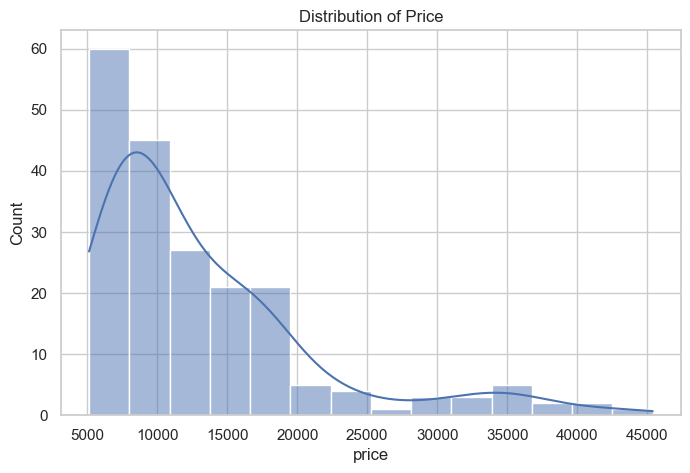

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(df["price"], kde=True)
plt.title("Distribution of Price")
plt.show()

#### Correlation Heatmap

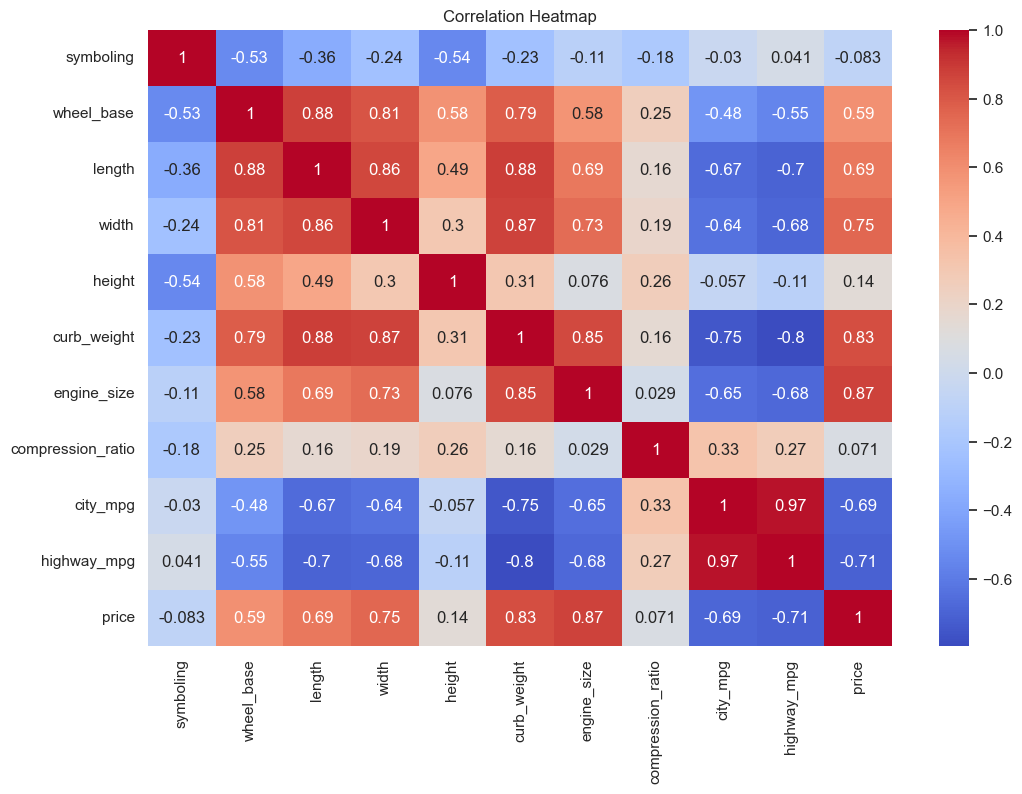

In [8]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

#### Engine Size vs Price

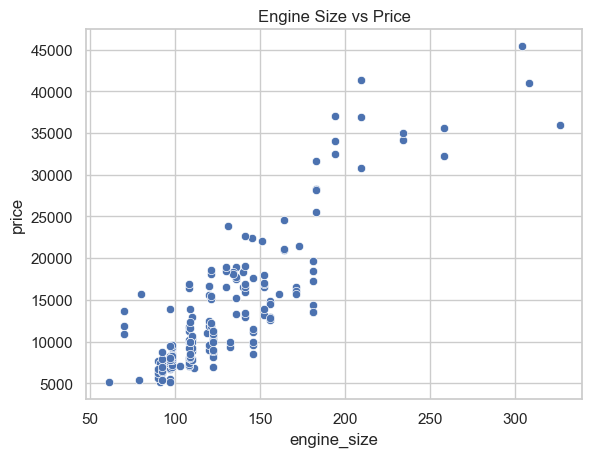

In [9]:
sns.scatterplot(x=df["engine_size"], y=df["price"])
plt.title("Engine Size vs Price")
plt.show()

#### Horsepower & Curb_Weight

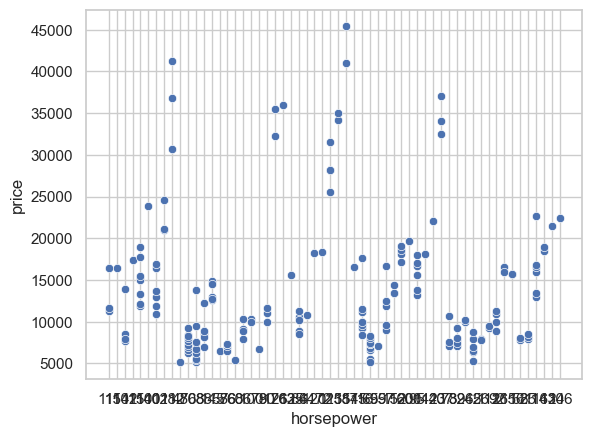

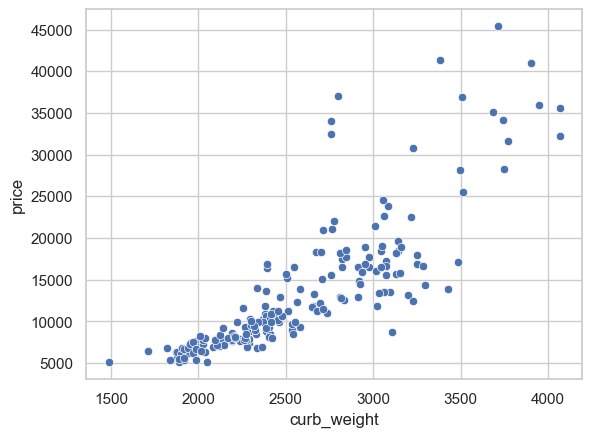

In [10]:
sns.scatterplot(x=df["horsepower"], y=df["price"])
plt.show()

sns.scatterplot(x=df["curb_weight"], y=df["price"])
plt.show()

#### Price

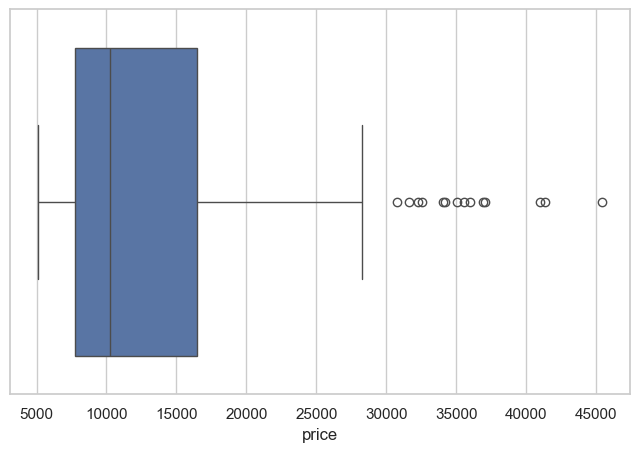

In [11]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["price"])
plt.show()

## Thí nghiệm 2: Tiền xử lý dữ liệu

#### -Ngày thực hiện: 4/3/2026

#### -Người thực hiện: Trần Tấn Phát
#### Mục đích:
#### - Làm sạch dữ liệu và chuẩn bị cho mô hình học máy

#### Nội dung:
#### - Chuyển các cột dữ liệu về đúng kiểu số
#### - Xử lý giá trị thiếu bằng trung bình (mean) và giá trị phổ biến nhất (mode)
#### - Mã hóa dữ liệu dạng category bằng One-Hot Encoding
#### - Chuẩn hóa dữ liệu bằng StandardScaler

#### Kết quả:
#### - Dữ liệu đã được làm sạch và không còn giá trị thiếu
#### - Tất cả các thuộc tính đã ở dạng số
#### - Dữ liệu sẵn sàng cho quá trình huấn luyện mô hình

#### Kiểm tra dữ liệu

In [12]:
df.dtypes

symboling              int64
normalized_losses        str
make                     str
fuel_type                str
aspiration               str
num_of_doors             str
body_style               str
drive_wheels             str
engine_location          str
wheel_base           float64
length               float64
width                float64
height               float64
curb_weight            int64
engine_type              str
num_of_cylinders         str
engine_size            int64
fuel_system              str
bore                     str
stroke                   str
compression_ratio    float64
horsepower               str
peak_rpm                 str
city_mpg               int64
highway_mpg            int64
price                  int64
dtype: object

#### Chuyển đổi dữ liệu sang số

In [13]:
cols_to_convert = ["normalized_losses", "bore", "stroke", "horsepower", "peak_rpm", "price"]

for col in cols_to_convert:
    df[col] = pd.to_numeric(df[col])

#### Xử lý MISSING VALUE

In [28]:
df_before = df.copy()
#Cột categorical
cat_cols = df.select_dtypes(include=['object', 'string']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Cột số
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].mean())
print("=== MISSING BEFORE ===")
print(df_before.isnull().sum())

print("\n=== MISSING AFTER ===")
print(df.isnull().sum())
print(df_before.isnull().sum().sum())

=== MISSING BEFORE ===
symboling            0
normalized_losses    0
wheel_base           0
length               0
width                0
                    ..
fuel_system_idi      0
fuel_system_mfi      0
fuel_system_mpfi     0
fuel_system_spdi     0
fuel_system_spfi     0
Length: 65, dtype: int64

=== MISSING AFTER ===
symboling            0
normalized_losses    0
wheel_base           0
length               0
width                0
                    ..
fuel_system_idi      0
fuel_system_mfi      0
fuel_system_mpfi     0
fuel_system_spdi     0
fuel_system_spfi     0
Length: 65, dtype: int64
0


#### Chuẩn hóa dữ liệu

In [15]:
df = pd.get_dummies(df, drop_first=True)

#### Tách x và y

In [16]:
X = df.drop("price", axis=1)
y = df["price"]

#### Chuẩn hóa

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#### TRAIN 10 MODELS

#### Thí nghiệm 3: Huấn luyện mô hình

**Thời gian thực hiện:** 3/4/2026  
**Người thực hiện:** Trần Tấn Phát

---

### 1. Mục đích
* So sánh hiệu suất của nhiều thuật toán hồi quy khác nhau trên tập dữ liệu.

### 2. Nội dung thực hiện
* Áp dụng **10 thuật toán** hồi quy (Linear, Decision Tree, Ensemble Learning,...).
* Đánh giá và so sánh dựa trên các chỉ số: $MSE$, $RMSE$ và $R^2$.

### 3. Kết quả ghi nhận
* **Random Forest** và **Gradient Boosting** đạt độ chính xác cao nhất.
* Các mô hình tuyến tính (**Linear Regression**) có hiệu suất thấp hơn rõ rệt.
* **Kết luận:** Mối quan hệ giữa các biến trong tập dữ liệu mang tính phi tuyến tính. 

#### CHIA DATA

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)

#### Khởi tạo thư viện 10 thuật toán


In [19]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import AdaBoostRegressor

#### Tạo danh sách Model

In [20]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(),
    "Gradient Boosting": GradientBoostingRegressor(),
    "KNN": KNeighborsRegressor(),
    "SVR": SVR(),
    "MLP": MLPRegressor(max_iter=500),
    "AdaBoost": AdaBoostRegressor()
}

#### Train và Evaluate

In [21]:
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import numpy as np

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    results.append([name, mse, rmse, r2])

results_df = pd.DataFrame(results, columns=["Model", "MSE", "RMSE", "R2"])

print(results_df.sort_values(by="R2", ascending=False))

c:\Users\admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.314e+06, tolerance: 7.159e+05
  model = cd_fast.enet_coordinate_descent(
c:\Users\admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


               Model           MSE          RMSE        R2
5  Gradient Boosting  2.542834e+06   1594.626599  0.971920
4      Random Forest  3.304634e+06   1817.865248  0.963508
9           AdaBoost  5.525544e+06   2350.647529  0.938983
1              Ridge  7.647269e+06   2765.369673  0.915553
3      Decision Tree  8.049290e+06   2837.127092  0.911114
2              Lasso  1.968533e+07   4436.815040  0.782621
0  Linear Regression  2.138748e+07   4624.660527  0.763824
6                KNN  2.819234e+07   5309.646355  0.688680
7                SVR  1.002629e+08  10013.137406 -0.107175
8                MLP  2.671199e+08  16343.802868 -1.949728


In [22]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor

param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.01, 0.1],
    "max_depth": [3, 5]
}

grid = GridSearchCV(
    GradientBoostingRegressor(),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)
print("Best Score:", grid.best_score_)
print("Final R2:", r2_score(y_test, y_pred))
print(df.isnull().sum())

Best Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Best Score: 0.8093588331710494
Final R2: 0.9389830112021542
symboling            0
normalized_losses    0
wheel_base           0
length               0
width                0
                    ..
fuel_system_idi      0
fuel_system_mfi      0
fuel_system_mpfi     0
fuel_system_spdi     0
fuel_system_spfi     0
Length: 65, dtype: int64


#### ĐÁNH GIÁ MODEL

In [23]:
X = df.drop("price", axis=1)
y = df["price"]
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [24]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20]
}

grid = GridSearchCV(
    RandomForestRegressor(),
    param_grid,
    cv=5,
    scoring="neg_mean_squared_error"
)

grid.fit(X_train, y_train)
best_model = grid.best_estimator_

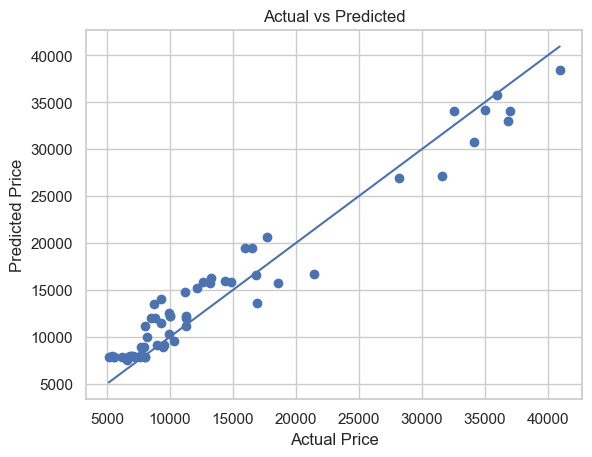

In [25]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")

# Vẽ đường chéo (perfect prediction)
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()])

plt.show()

#### Biểu đồ RESIDUAL PLOT

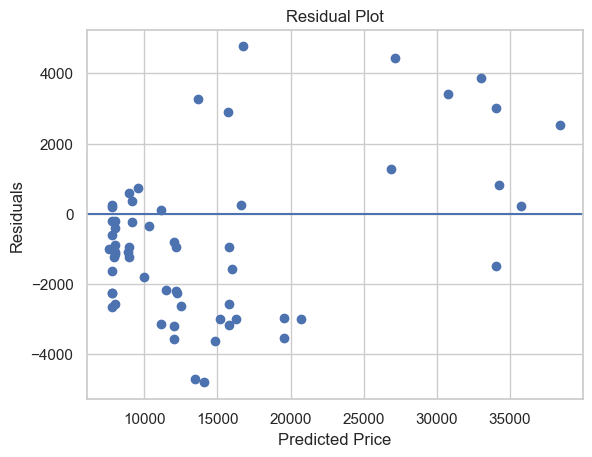

In [26]:
residuals = y_test - y_pred

plt.figure()
plt.scatter(y_pred, residuals)

plt.axhline(y=0)  # đường ngang tại 0

plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()